# Generate synthesis dataset

In [1]:
import torch
from torch.utils.data import TensorDataset, random_split, DataLoader

# Parameters
n_pixels = 128        # number of pixels (like visible units)
num_samples = 10000    # total synthetic image samples
num_classes = 10  # arbitrary number of classes
batch_size = 64
n_features = 1000        # audio features per sample (like visible units)

# Generate random binary "image" dataset
image_data = torch.bernoulli(torch.rand(num_samples, n_pixels))

# Generate random binary "audio" dataset
audio_waveforms = torch.bernoulli(torch.rand(num_samples, n_features))

# Generate random integer labels between 0 and num_classes-1
y = torch.randint(0, num_classes, (num_samples,))

# Wrap into a TensorDataset
dataset = TensorDataset(audio_waveforms, image_data, y)

# Train/test split (80/20)
train_size = int(0.8 * num_samples)
test_size = num_samples - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])

# Create DataLoaders
labeled_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)

print(f"Train batches: {len(labeled_dataloader)}, Test batches: {len(test_loader)}")


Train batches: 125, Test batches: 32


# Define RBM model

In [2]:
import torch.nn as nn
import torch.nn.functional as F
class RBM(nn.Module):##This line defines a new class named RBM that inherits from nn.Module

    def __init__(self, n_vis=784, n_hin=500, k=5):##This is the constructor method for the RBM class.
              #n_vis: The number of visible units (input units). Default is 784.
             #n_hin: The number of hidden units. Default is 500.
             #k: The number of Gibbs sampling steps to perform during training. Default is 5.""
        super(RBM, self).__init__()
        self.n_vis = n_vis
        self.n_hin = n_hin
        self.k = k
        # Initialize model parameters with random values
        self.W = nn.Parameter(torch.randn(n_hin, n_vis) * 1e-2)
        self.v_bias = nn.Parameter(torch.zeros(n_vis))
        self.h_bias = nn.Parameter(torch.zeros(n_hin))

    def sample_from_p(self, p):##torch.bernoulli(p) samples binary values from the probability distribution p directly
        return torch.bernoulli(p)


    def v_to_h(self, v):
        activations = torch.sigmoid(F.linear(v, self.W, self.h_bias))
        sample_h = torch.bernoulli(activations)
        return activations, sample_h


    def h_to_v(self,h):
        p_v = F.sigmoid(F.linear(h,self.W.t(),self.v_bias))
        sample_v = self.sample_from_p(p_v)
        return p_v,sample_v

    def forward(self,v):
        pre_h1,h1 = self.v_to_h(v)

        h_ = h1
        for _ in range(self.k):
            pre_v_,v_ = self.h_to_v(h_)
            pre_h_,h_ = self.v_to_h(v_)

        return v,v_

    def free_energy(self, v):
        vbias_term = torch.matmul(v, self.v_bias).sum()
        wx_b = torch.matmul(v, self.W.t()) + self.h_bias
        hidden_term = torch.sum(torch.log1p(torch.exp(wx_b)), dim=1)
        return -(hidden_term + vbias_term).mean()

    def get_hidden_posteriors(self, data):
        """
        After training, extract hidden posteriors.
        sigmoid(Wv + b) gives hidden probabilities.
        """
        return torch.sigmoid(torch.matmul(data, self.W.t()) + self.h_bias)

# RBM visual

## Train and Eval

In [3]:
import torch.optim as optim
rbm_img = RBM(n_vis=128, k=5)
train_op = optim.SGD(rbm_img.parameters(), 0.1)
# Initialize a list to store training loss per epoch
training_loss = []

for epoch in range(5):
    total_loss = 0.0  # To accumulate the total loss for this epoch

    for aud, img, lbl in labeled_dataloader:
        data = img
        sample_data = torch.bernoulli(data)

        v, v1 = rbm_img(sample_data)
        loss = rbm_img.free_energy(v) - rbm_img.free_energy(v1)

        total_loss += loss.item()  # Accumulate the loss
        train_op.zero_grad()
        loss.backward()
        train_op.step()

    average_loss = total_loss / len(labeled_dataloader)
    training_loss.append(average_loss)
    print("Training loss for {} epoch: {:.4f}".format(epoch, average_loss))

Training loss for 0 epoch: 3211.9671
Training loss for 1 epoch: 2177.0412
Training loss for 2 epoch: 1813.0124
Training loss for 3 epoch: 1488.4502
Training loss for 4 epoch: 1364.9212


In [4]:
# Initialize a list to store test loss per epoch
test_loss = []

for epoch in range(5):
    # Training (similar to your previous code)
    total_loss = 0.0



    # Testing (calculate test loss)
    total_test_loss = 0.0

    with torch.no_grad():  # Disable gradient computation for testing
        for aud, img, lbl in test_loader:
            data = img
            sample_data = torch.bernoulli(data)

            v, v1 = rbm_img(sample_data)
            test_loss_item = rbm_img.free_energy(v) - rbm_img.free_energy(v1)

            total_test_loss += test_loss_item.item()

    average_test_loss = total_test_loss / len(test_loader)
    test_loss.append(average_test_loss)

    print("Epoch {} , Test Loss: {:.4f}".format(epoch, average_test_loss))


Epoch 0 , Test Loss: 314.3584
Epoch 1 , Test Loss: 301.1132
Epoch 2 , Test Loss: 298.9718
Epoch 3 , Test Loss: 315.5429
Epoch 4 , Test Loss: 301.3847


## Visual

### Training lost

ValueError: x and y must have same first dimension, but have shapes (50,) and (5,)

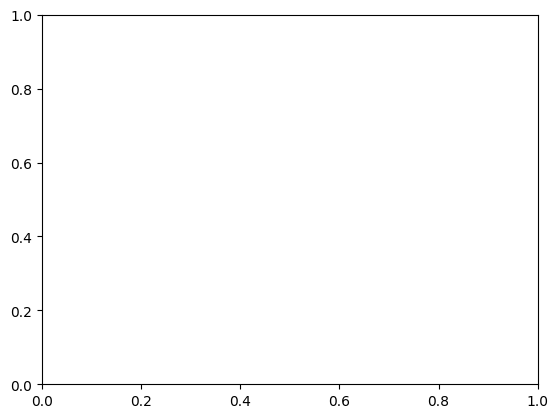

In [5]:
import matplotlib.pyplot as plt
# Plot the training loss
plt.plot(range(1, 51), training_loss, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

### Energy Distribution

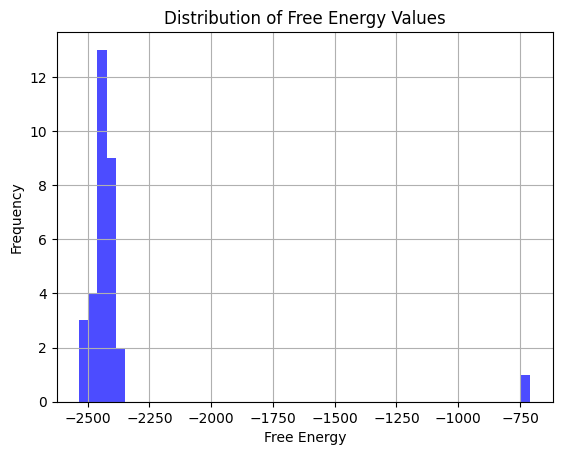

In [6]:
import numpy as np
# Initialize an empty list to store free energy values
free_energy_values = []

# Loop through the dataset and calculate free energy for each sample
for aud, img, lbl in test_loader:
    data = img
    with torch.no_grad():
        free_energy = rbm_img.free_energy(data).item()
    free_energy_values.append(free_energy)

# Convert the list of free energy values to a NumPy array
free_energy_values = np.array(free_energy_values)

# Plot a histogram of free energy values
num_bins = 50  # Number of bins for the histogram
plt.hist(free_energy_values, bins=num_bins, color='blue', alpha=0.7)
plt.xlabel('Free Energy')
plt.ylabel('Frequency')
plt.title('Distribution of Free Energy Values')
plt.grid(True)
plt.show()


# RBM Audio

## Train and Eval

In [7]:
import torch.optim as optim
rbm_aud = RBM(n_vis=1000, k=5)
train_op = optim.SGD(rbm_aud.parameters(), 0.1)
# Initialize a list to store training loss per epoch
training_loss = []

for epoch in range(5):
    total_loss = 0.0  # To accumulate the total loss for this epoch

    for aud, img, lbl in labeled_dataloader:
        data = aud
        sample_data = torch.bernoulli(data)

        v, v1 = rbm_aud(sample_data)
        loss = rbm_aud.free_energy(v) - rbm_aud.free_energy(v1)

        total_loss += loss.item()  # Accumulate the loss
        train_op.zero_grad()
        loss.backward()
        train_op.step()

    average_loss = total_loss / len(labeled_dataloader)
    training_loss.append(average_loss)
    print("Training loss for {} epoch: {:.4f}".format(epoch, average_loss))

Training loss for 0 epoch: 6410.9857
Training loss for 1 epoch: 5785.3385
Training loss for 2 epoch: 5896.5185
Training loss for 3 epoch: 5883.0913
Training loss for 4 epoch: 5843.6113


In [8]:
# Initialize a list to store test loss per epoch
test_loss = []

for epoch in range(5):
    # Training (similar to your previous code)
    total_loss = 0.0



    # Testing (calculate test loss)
    total_test_loss = 0.0

    with torch.no_grad():  # Disable gradient computation for testing
        for aud, img, lbl in test_loader:
            data = aud
            sample_data = torch.bernoulli(data)

            v, v1 = rbm_aud(sample_data)
            test_loss_item = rbm_aud.free_energy(v) - rbm_aud.free_energy(v1)

            total_test_loss += test_loss_item.item()

    average_test_loss = total_test_loss / len(test_loader)
    test_loss.append(average_test_loss)

    print("Epoch {} , Test Loss: {:.4f}".format(epoch, average_test_loss))


Epoch 0 , Test Loss: 5434.6160
Epoch 1 , Test Loss: 5432.1192
Epoch 2 , Test Loss: 5435.3567
Epoch 3 , Test Loss: 5433.5569
Epoch 4 , Test Loss: 5439.3661


## Visual

### Training lost

ValueError: x and y must have same first dimension, but have shapes (50,) and (5,)

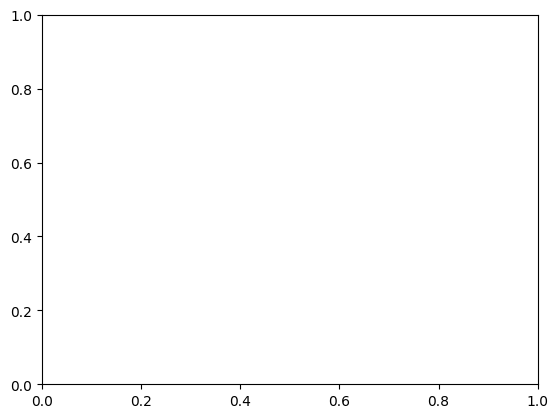

In [9]:
import matplotlib.pyplot as plt
# Plot the training loss
plt.plot(range(1, 51), training_loss, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

### Energy Distribution

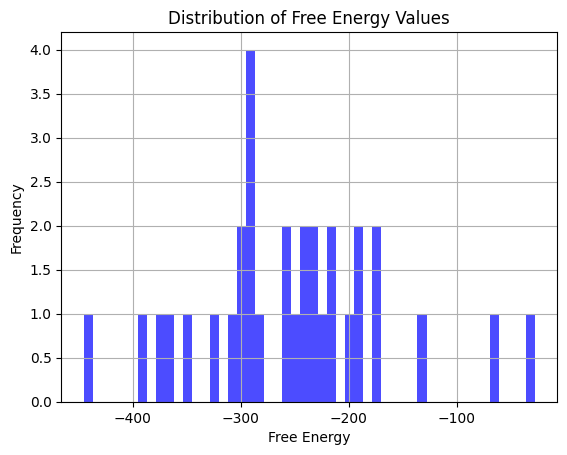

In [10]:
import numpy as np
# Initialize an empty list to store free energy values
free_energy_values = []

# Loop through the dataset and calculate free energy for each sample
for aud, img, lbl in test_loader:
    data = aud  # unpack
    with torch.no_grad():
        free_energy = rbm_aud.free_energy(data).item()
    free_energy_values.append(free_energy)

# Convert the list of free energy values to a NumPy array
free_energy_values = np.array(free_energy_values)

# Plot a histogram of free energy values
num_bins = 50  # Number of bins for the histogram
plt.hist(free_energy_values, bins=num_bins, color='blue', alpha=0.7)
plt.xlabel('Free Energy')
plt.ylabel('Frequency')
plt.title('Distribution of Free Energy Values')
plt.grid(True)
plt.show()


# Hidden (figure 2c) (figure 2d)

## Definition

In [11]:
# Shared hidden RBM
rbm_joint = RBM(n_vis=rbm_aud.n_vis + rbm_img.n_vis, k=5) # takes concat of audio+visual hidden (500+500)

# Reconstruction RBMs
recon_rbm_aud = RBM(n_vis=128, n_hin=1000)  # hidden→audio reconstruction
recon_rbm_img = RBM(n_vis=128, n_hin=128)   # hidden→visual reconstruction

### 2c

In [12]:
# Assume aud_dim and img_dim are the sizes of your audio and video feature vectors
train_op = optim.SGD(rbm_joint.parameters(), lr=0.1)

for epoch in range(5):
    total_loss = 0.0
    for aud, img, lbl in labeled_dataloader:
        # Concatenate raw audio and video features
        data = torch.cat([aud, img], dim=1)
        sample_data = torch.bernoulli(data)

        v, v1 = rbm_joint(sample_data)
        loss = rbm_joint.free_energy(v) - rbm_joint.free_energy(v1)

        total_loss += loss.item()
        train_op.zero_grad()
        loss.backward()
        train_op.step()

    print(f"Epoch {epoch}, loss: {total_loss / len(labeled_dataloader):.4f}")


Epoch 0, loss: 7256.8298
Epoch 1, loss: 6608.3033
Epoch 2, loss: 6643.5872
Epoch 3, loss: 6627.7609
Epoch 4, loss: 6607.7424


### 2d

In [13]:
# After training, extract hidden posteriors
def get_hidden_posteriors(rbm, data):
    # sigmoid(Wv + b) gives hidden probabilities
    return torch.sigmoid(torch.matmul(data, rbm.W.t()) + rbm.h_bias)

rbm_bimodal = RBM(n_vis=rbm_aud.n_hin + rbm_img.n_hin, k=5)
train_op = optim.SGD(rbm_bimodal.parameters(), lr=0.1)

for epoch in range(5):
    total_loss = 0.0
    for aud, img, lbl in labeled_dataloader:
        # Get hidden representations from unimodal RBMs
        h_aud = get_hidden_posteriors(rbm_aud, aud)
        h_img = get_hidden_posteriors(rbm_img, img)

        # Concatenate hidden features
        data = torch.cat([h_aud, h_img], dim=1)
        sample_data = torch.bernoulli(data)

        v, v1 = rbm_bimodal(sample_data)
        loss = rbm_bimodal.free_energy(v) - rbm_bimodal.free_energy(v1)

        total_loss += loss.item()
        train_op.zero_grad()
        loss.backward()
        train_op.step()

    print(f"Epoch {epoch}, loss: {total_loss / len(labeled_dataloader):.4f}")


Epoch 0, loss: 1135.4128
Epoch 1, loss: 901.5248
Epoch 2, loss: 819.9203
Epoch 3, loss: 746.5112
Epoch 4, loss: 733.0996


# Decoder (3a)

## Definition

In [14]:
class DeepAutoencoder(nn.Module):
    def __init__(self, rbm_aud, rbm_img, rbm_bimodal):
        super().__init__()
        # Encoder weights initialized from RBMs
        self.enc_video = nn.Linear(rbm_img.n_vis, rbm_img.n_hin)
        self.enc_audio = nn.Linear(rbm_aud.n_vis, rbm_aud.n_hin)
        self.enc_joint = nn.Linear(rbm_img.n_hin + rbm_aud.n_hin, rbm_bimodal.n_hin)

        # Decoder weights (mirror of encoder)
        self.dec_joint = nn.Linear(rbm_bimodal.n_hin, rbm_img.n_hin + rbm_aud.n_hin)
        self.dec_video = nn.Linear(rbm_img.n_hin, rbm_img.n_vis)
        self.dec_audio = nn.Linear(rbm_aud.n_hin, rbm_aud.n_vis)

        # Initialize with RBM weights
        self.enc_video.weight.data = rbm_img.W.clone()
        self.enc_video.bias.data = rbm_img.h_bias.clone()
        self.enc_audio.weight.data = rbm_aud.W.clone()
        self.enc_audio.bias.data = rbm_aud.h_bias.clone()
        self.enc_joint.weight.data = rbm_bimodal.W.clone()
        self.enc_joint.bias.data = rbm_bimodal.h_bias.clone()

    def forward(self, aud=None, img=None, modality="video"):
        if modality == "video":
            h_video = torch.sigmoid(self.enc_video(img))
            # concatenate with zeros for audio
            h_audio = torch.zeros(img.size(0), self.enc_audio.out_features, device=img.device)
            h_joint = torch.sigmoid(self.enc_joint(torch.cat([h_video, h_audio], dim=1)))
        elif modality == "audio":
            h_audio = torch.sigmoid(self.enc_audio(aud))
            h_video = torch.zeros(aud.size(0), self.enc_video.out_features, device=aud.device)
            h_joint = torch.sigmoid(self.enc_joint(torch.cat([h_video, h_audio], dim=1)))
        else:  # both
            h_video = torch.sigmoid(self.enc_video(img))
            h_audio = torch.sigmoid(self.enc_audio(aud))
            h_joint = torch.sigmoid(self.enc_joint(torch.cat([h_video, h_audio], dim=1)))

        # Decode
        h_dec = torch.sigmoid(self.dec_joint(h_joint))
        v_recon = torch.sigmoid(self.dec_video(h_dec[:, :rbm_img.n_hin]))
        a_recon = torch.sigmoid(self.dec_audio(h_dec[:, rbm_img.n_hin:]))

        return v_recon, a_recon, h_joint  # h_joint is the shared representation


## Training

In [15]:
autoenc = DeepAutoencoder(rbm_aud, rbm_img, rbm_bimodal)
optimizer = optim.Adam(autoenc.parameters(), lr=1e-3)

for epoch in range(5):
    total_loss = 0.0
    for aud, img, lbl in labeled_dataloader:
        v_recon, a_recon, h_joint = autoenc(img=img, modality="video")

        # Reconstruction loss: reconstruct both modalities
        loss = F.mse_loss(v_recon, img) + F.mse_loss(a_recon, aud)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Autoencoder epoch {epoch}, loss {total_loss/len(labeled_dataloader):.4f}")

Autoencoder epoch 0, loss 0.5012
Autoencoder epoch 1, loss 0.5001
Autoencoder epoch 2, loss 0.5000
Autoencoder epoch 3, loss 0.4997
Autoencoder epoch 4, loss 0.4983


## Classification with SVM

### Train

In [16]:
features = []
labels = []

# Extract features from autoencoder
for aud, img, lbl in labeled_dataloader:
    _, _, h_joint = autoenc(img=img, modality="video")  # middle layer
    features.append(h_joint.detach().cpu().numpy())
    labels.append(lbl.cpu().numpy())

X = np.vstack(features)
y = np.hstack(labels)

# Train a linear SVM
from sklearn.svm import LinearSVC
clf = LinearSVC()
clf.fit(X, y)

# Evaluate
acc = clf.score(X, y)
print("Training accuracy:", acc)

Training accuracy: 0.115125


### Evaluate

In [17]:
features = []
labels = []

# Extract features from autoencoder
for aud, img, lbl in test_loader:
    _, _, h_joint = autoenc(img=img, modality="video")  # middle layer
    features.append(h_joint.detach().cpu().numpy())
    labels.append(lbl.cpu().numpy())

X = np.vstack(features)
y = np.hstack(labels)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred))

Accuracy: 0.099

Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.28      0.17       207
           1       0.11      0.05      0.07       200
           2       0.00      0.00      0.00       189
           3       0.05      0.07      0.06       169
           4       0.11      0.10      0.10       217
           5       0.10      0.21      0.13       195
           6       0.33      0.01      0.03       227
           7       0.10      0.17      0.12       212
           8       0.08      0.11      0.09       179
           9       0.00      0.00      0.00       205

    accuracy                           0.10      2000
   macro avg       0.10      0.10      0.08      2000
weighted avg       0.11      0.10      0.08      2000


Confusion Matrix:
 [[57 10  0 25 14 34  1 40 26  0]
 [48 10  0 19 17 39  2 40 25  0]
 [38 15  0 22 12 36  1 44 21  0]
 [52  5  0 12 16 36  0 28 20  0]
 [52 10  0 21 21 43  1 29 40  0]
 [41 14  0 18 2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Bimodal Denoising Autoencoder (3b)

## Definition

In [18]:
class BimodalDenoisingAutoencoder(nn.Module):
    def __init__(self, rbm_aud, rbm_img, rbm_bimodal):
        super().__init__()
        # Encoder
        self.enc_audio = nn.Linear(rbm_aud.n_vis, rbm_aud.n_hin)
        self.enc_video = nn.Linear(rbm_img.n_vis, rbm_img.n_hin)
        self.enc_joint = nn.Linear(rbm_aud.n_hin + rbm_img.n_hin, rbm_bimodal.n_hin)

        # Decoder
        self.dec_joint = nn.Linear(rbm_bimodal.n_hin, rbm_aud.n_hin + rbm_img.n_hin)
        self.dec_audio = nn.Linear(rbm_aud.n_hin, rbm_aud.n_vis)
        self.dec_video = nn.Linear(rbm_img.n_hin, rbm_img.n_vis)

        # Initialize with RBM weights
        self.enc_audio.weight.data = rbm_aud.W.clone()
        self.enc_audio.bias.data = rbm_aud.h_bias.clone()
        self.enc_video.weight.data = rbm_img.W.clone()
        self.enc_video.bias.data = rbm_img.h_bias.clone()
        self.enc_joint.weight.data = rbm_bimodal.W.clone()
        self.enc_joint.bias.data = rbm_bimodal.h_bias.clone()

    def forward(self, aud, img):
        # Encode
        h_audio = torch.sigmoid(self.enc_audio(aud))
        h_video = torch.sigmoid(self.enc_video(img))
        h_joint = torch.sigmoid(self.enc_joint(torch.cat([h_audio, h_video], dim=1)))

        # Decode
        h_dec = torch.sigmoid(self.dec_joint(h_joint))
        a_recon = torch.sigmoid(self.dec_audio(h_dec[:, :self.enc_audio.out_features]))
        v_recon = torch.sigmoid(self.dec_video(h_dec[:, self.enc_audio.out_features:]))

        return a_recon, v_recon, h_joint


## Train

In [19]:
autoenc = BimodalDenoisingAutoencoder(rbm_aud, rbm_img, rbm_bimodal)
optimizer = optim.Adam(autoenc.parameters(), lr=1e-3)

for epoch in range(5):
    total_loss = 0.0
    for aud, img, lbl in labeled_dataloader:
        # Randomly choose modality setting
        r = torch.rand(1).item()
        if r < 0.33:   # video-only
            aud_in = torch.zeros_like(aud)
            img_in = img
        elif r < 0.66: # audio-only
            aud_in = aud
            img_in = torch.zeros_like(img)
        else:          # both modalities
            aud_in = aud
            img_in = img

        a_recon, v_recon, h_joint = autoenc(aud_in, img_in)

        # Reconstruction loss for both modalities
        loss = F.mse_loss(a_recon, aud) + F.mse_loss(v_recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Denoising Autoencoder epoch {epoch}, loss {total_loss/len(labeled_dataloader):.4f}")


Denoising Autoencoder epoch 0, loss 0.5018
Denoising Autoencoder epoch 1, loss 0.5000
Denoising Autoencoder epoch 2, loss 0.5000
Denoising Autoencoder epoch 3, loss 0.4999
Denoising Autoencoder epoch 4, loss 0.4998


## Classification with SVM

### Definition

In [20]:
import numpy as np

def slice_and_pool(features, S=3):
    """
    features: numpy array of shape [time_steps, feature_dim]
    S: number of slices (e.g., 1 or 3)

    Returns: pooled feature vector of shape [S * feature_dim]
    """
    T = features.shape[0]
    slice_len = T // S
    pooled = []
    for s in range(S):
        start = s * slice_len
        end = (s+1) * slice_len if s < S-1 else T
        slice_feats = features[start:end]
        avg = slice_feats.mean(axis=0)
        pooled.append(avg)
    return np.concatenate(pooled, axis=0)

### Generate data

In [29]:
features = []
labels = []

for aud, img, lbl in labeled_dataloader:
    for i in range(len(lbl)):
        # Audio: reshape one sample into [time_steps, feature_dim]
        aud_seq = aud[i].reshape(-1, 10)   # 100 time steps × 10 features
        pooled_aud = slice_and_pool(aud_seq, S=3)

        # Image: reshape one sample into [time_steps, feature_dim]
        img_seq = img[i].reshape(-1, 8)    # 16 time steps × 8 features
        pooled_img = slice_and_pool(img_seq, S=3)

        # Concatenate pooled features
        pooled_features = np.concatenate([pooled_aud, pooled_img], axis=0)

        features.append(pooled_features)
        labels.append(lbl[i].item())

features = np.vstack(features)   # shape (num_samples, feature_dim_total)
labels = np.array(labels)        # shape (num_samples,)


In [32]:
test_features = []
test_labels = []

for aud, img, lbl in test_loader:
    for i in range(len(lbl)):
        # Audio: reshape one sample into [time_steps, feature_dim]
        aud_seq = aud[i].reshape(-1, 10)   # 100 time steps × 10 features
        pooled_aud = slice_and_pool(aud_seq, S=3)

        # Image: reshape one sample into [time_steps, feature_dim]
        img_seq = img[i].reshape(-1, 8)    # 16 time steps × 8 features
        pooled_img = slice_and_pool(img_seq, S=3)

        # Concatenate pooled features
        pooled_features = np.concatenate([pooled_aud, pooled_img], axis=0)

        test_features.append(pooled_features)
        test_labels.append(lbl[i].item())

test_features = np.vstack(features)   # shape (num_samples, feature_dim_total)
test_labels = np.array(labels)        # shape (num_samples,)

### Train

In [31]:
from sklearn.svm import LinearSVC

clf = LinearSVC()
clf.fit(features, labels)

print("Train accuracy:", clf.score(features, labels))

Train accuracy: 0.142375


### Evaluate

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(test_features)

print("Accuracy:", accuracy_score(test_labels, y_pred))
print("\nClassification Report:\n", classification_report(test_labels, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(test_labels, y_pred))

Accuracy: 0.142375

Classification Report:
               precision    recall  f1-score   support

           0       0.14      0.10      0.12       804
           1       0.15      0.13      0.14       786
           2       0.14      0.10      0.12       745
           3       0.14      0.16      0.15       762
           4       0.15      0.15      0.15       797
           5       0.13      0.13      0.13       836
           6       0.15      0.15      0.15       806
           7       0.13      0.10      0.11       815
           8       0.15      0.19      0.17       843
           9       0.14      0.19      0.16       806

    accuracy                           0.14      8000
   macro avg       0.14      0.14      0.14      8000
weighted avg       0.14      0.14      0.14      8000


Confusion Matrix:
 [[ 84  74  65  92  71  89  71  56 100 102]
 [ 53 102  47  76  71  79  76  74 108 100]
 [ 51  57  77  81  65  77  72  71 101  93]
 [ 73  64  47 125  82  80  66  56  82  87]
 [ 53

### Definition

In [ ]:
def extract_hidden_features(dataloader):
    features = []
    labels = []

    for aud, img, lbl in dataloader:
        # Get hidden features from unimodal RBMs
        h_aud = rbm_aud.get_hidden_posteriors(aud)
        h_img = rbm_img.get_hidden_posteriors(img)

        # Concatenate for multimodal feature
        h_joint = torch.cat([h_aud, h_img], dim=1)

        # Optionally pass through bimodal RBM/DBN for higher-level features
        h_bimodal = rbm_bimodal.get_hidden_posteriors(h_joint)

        features.append(h_bimodal.detach().cpu().numpy())
        labels.append(lbl.cpu().numpy())
    return features, labels

### Data

In [ ]:
from sklearn.model_selection import train_test_split

features, labels = extract_hidden_features(labeled_dataloader)

X = np.vstack(features)   # your feature vectors
y = np.hstack(labels)     # corresponding labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Train

In [ ]:
# Train a linear SVM on these features
from sklearn.svm import LinearSVC

clf = LinearSVC(max_iter=5000)
clf.fit(X_train, y_train)


### Test

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

### Train Multimodal RBM (DBN Pretraining)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

def slice_and_pool(features, S=3):
    # features: (batch, time, dim)
    batch, time, dim = features.shape
    slice_len = time // S
    pooled = []
    for s in range(S):
        start = s * slice_len
        end = (s+1) * slice_len if s < S-1 else time
        pooled_slice = features[:, start:end, :].mean(dim=1)
        pooled.append(pooled_slice)
    return torch.cat(pooled, dim=1)  # (batch, S*dim)

# Collect features and labels
train_features, train_labels = [], []
test_features, test_labels = [], []

for batch_x1, batch_x2, labels in labeled_dataloader:
    # Encode audio and visual
    _, h_aud = rbm_aud.v_to_h(batch_x1)
    _, h_vid = rbm_img.v_to_h(batch_x2)
    h_concat = torch.cat([h_aud, h_vid], dim=1)
    _, h_shared = rbm_joint.v_to_h(h_concat)

    # If sequential, reshape h_shared to (batch, time, dim) before pooling
    # For static inputs, skip pooling
    pooled = h_shared # slice_and_pool(h_shared.unsqueeze(1), S=3)  # add fake time dim if needed

    train_features.append(pooled.detach().cpu())
    train_labels.append(labels.detach().cpu())

# Convert to numpy for SVM
X_train = torch.cat(train_features).numpy()
y_train = torch.cat(train_labels).numpy()

# Create a mask for rows without NaN
mask = ~np.isnan(X_train).any(axis=1)

# Apply mask to both X and y
X_clean = X_train[mask]
y_clean = y_train[mask]

# Train linear SVM
svm = LinearSVC()
svm.fit(X_clean, y_clean)

# Evaluate on test set
for batch_x1, batch_x2, labels in test_loader:
    _, h_aud = rbm_aud.v_to_h(batch_x1)
    _, h_vid = rbm_img.v_to_h(batch_x2)
    h_concat = torch.cat([h_aud, h_vid], dim=1)
    _, h_shared = rbm_joint.v_to_h(h_concat)
    pooled = h_shared # slice_and_pool(h_shared.unsqueeze(1), S=3)

    test_features.append(pooled.detach().cpu())
    test_labels.append(labels.detach().cpu())

X_test = torch.cat(test_features).numpy()
y_test = torch.cat(test_labels).numpy()

y_pred = svm.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))


## Definition

In [ ]:
def multimodal_forward(audio_input, visual_input):
    # Encode audio and visual separately
    _, h_aud = rbm_aud.v_to_h(audio_input)
    _, h_vid = rbm_img.v_to_h(visual_input)


    # Concatenate hidden features
    h_concat = torch.cat([h_aud, h_vid], dim=0)

    # Shared hidden RBM
    _, h_shared = rbm_hidden.v_to_h(h_concat)
    print(h_shared.shape)

    # Reconstruct audio and visual
    _, recon_aud = recon_rbm_aud.h_to_v(h_shared.T)
    _, recon_vid = recon_rbm_img.h_to_v(h_shared.T)

    return recon_aud, recon_vid

# ----- Feature extraction with pooling -----
def extract_reconstructed_features(audio_seq, video_seq, S=3):
    """
    audio_seq: (T, audio_dim)
    video_seq: (T, video_dim)
    """
    with torch.no_grad():
        a_recon, v_recon = multimodal_forward(audio_seq, video_seq)  # (T, audio_dim), (T, video_dim)

    T = a_recon.shape[0]
    slice_len = T // S
    pooled_features = []
    for s in range(S):
        start = s * slice_len
        end = (s+1) * slice_len if s < S-1 else T
        a_slice = a_recon[start:end].mean(dim=0)
        v_slice = v_recon[start:end].mean(dim=0)
        pooled_features.append(torch.cat([a_slice, v_slice], dim=0))

    final_feat = torch.cat(pooled_features, dim=0)  # shape (S*(audio_dim+video_dim),)
    return final_feat.numpy()

## Feature Dataset

In [ ]:
X_train_features = []
y_train_labels = []
for batch_x1, batch_x2, labels in labeled_dataloader:
    # batch_x1: (batch_size, T, audio_dim)
    # batch_x2: (batch_size, T, video_dim)
    for i in range(batch_x1.size(0)):
        feat = extract_reconstructed_features(batch_x1[i], batch_x2[i], S=3)
        X_train_features.append(feat)
        y_train_labels.append(labels[i].item())

X_train_features = torch.cat(X_train_features).numpy()
y_train_labels = torch.cat(y_train_labels).numpy()

# Repeat for test set
X_test_features = []
y_test_labels = []

for batch_x1, batch_x2, labels in test_loader:
    # batch_x1: (batch_size, T, audio_dim)
    # batch_x2: (batch_size, T, video_dim)
    for i in range(batch_x1.size(0)):
        feat = extract_reconstructed_features(batch_x1[i], batch_x2[i], S=3)
        X_test_features.append(feat)
        y_test_labels.append(labels[i].item())

X_test_features = torch.cat(X_test_features).numpy()
y_test_labels = torch.cat(y_test_labels).numpy()

In [ ]:
print(h_shared.shape)

## Train

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

# ----- Train linear SVM -----
svm = make_pipeline(StandardScaler(), LinearSVC())
svm.fit(X_train_features, y_train_labels)
print("Training accuracy:", svm.score(X_train_features, y_train_labels))

## Hidden Dataset

In [ ]:
hidden_inputs = []
hidden_label = []
for aud, img, lbl in labeled_dataloader:
    _, h_aud = rbm_aud.v_to_h(aud)
    _, h_vid = rbm_img.v_to_h(img)
    h_concat = torch.cat([h_aud, h_vid], dim=1)
    hidden_inputs.append(h_concat)
    # h_label_concat = torch.cat([a_label, v_label], dim=1)
    hidden_label.append(lbl)

hidden_inputs = torch.cat(hidden_inputs, dim=0)
hidden_label = torch.cat(hidden_label, dim=0)
hidden_loader = DataLoader(torch.utils.data.TensorDataset(hidden_inputs, hidden_label), batch_size=64, shuffle=True)

hidden_inputs = []
hidden_label = []
for aud, img, lbl in test_loader:
    _, h_aud = rbm_aud.v_to_h(aud)
    _, h_vid = rbm_img.v_to_h(img)
    h_concat = torch.cat([h_aud, h_vid], dim=1)
    hidden_inputs.append(h_concat)
    # h_label_concat = torch.cat([a_label, v_label], dim=1)
    hidden_label.append(lbl)

hidden_inputs = torch.cat(hidden_inputs, dim=0)
hidden_label = torch.cat(hidden_label, dim=0)
test_hidden_loader = DataLoader(torch.utils.data.TensorDataset(hidden_inputs, hidden_label), batch_size=64, shuffle=True)

## Train

In [ ]:
# Train audio RBM
# opt_aud = torch.optim.Adam(rbm_aud.parameters(), lr=1e-3)
# train_and_test_rbm(rbm_aud, audio_train_loader, opt_aud)

# Train visual RBM
# opt_vid = torch.optim.Adam(rbm_img.parameters(), lr=1e-3)
# train_and_test_rbm(rbm_img, img_train_loader, opt_vid)

# --- Step 2: Train shared hidden RBM ---

opt_hidden = torch.optim.Adam(rbm_hidden.parameters(), lr=1e-3)
train_loss_hin = train_and_test_rbm(rbm_hidden, hidden_loader, opt_hidden)

## Reconstruct Dataset

In [ ]:
recon_inputs = []
recon_label = []
for h_batch, h_label in hidden_loader:
    _, h_shared = rbm_hidden.v_to_h(h_batch)
    recon_inputs.append(h_shared)
    recon_label.append(h_label)

recon_inputs = torch.cat(recon_inputs, dim=0)
recon_label = torch.cat(recon_label, dim=0)
recon_loader = DataLoader(torch.utils.data.TensorDataset(recon_inputs, recon_label), batch_size=64, shuffle=True)

recon_inputs = []
recon_label = []
for h_batch, h_label in test_hidden_loader:
    _, h_shared = rbm_hidden.v_to_h(h_batch)
    recon_inputs.append(h_shared)
    recon_label.append(h_label)

recon_inputs = torch.cat(recon_inputs, dim=0)
recon_label = torch.cat(recon_label, dim=0)
test_recon_loader = DataLoader(torch.utils.data.TensorDataset(recon_inputs, recon_label), batch_size=64, shuffle=True)

In [ ]:
# --- Step 3: Train reconstruction RBMs ---

opt_recon_aud = torch.optim.Adam(recon_rbm_aud.parameters(), lr=1e-3)
opt_recon_vid = torch.optim.Adam(recon_rbm_img.parameters(), lr=1e-3)

train_loss_rec_aud = train_and_test_rbm(recon_rbm_aud, recon_loader, opt_recon_aud)
train_loss_rec_img = train_and_test_rbm(recon_rbm_img, recon_loader, opt_recon_vid)

## Evaluate

### Definition

In [ ]:
def evaluate_rbm(rbm_aud, audio_test_loader, epochs=50):
    # Initialize a list to store test loss per epoch
    test_loss = []

    for epoch in range(epochs):
        # Training (placeholder, similar to your previous code)
        total_loss = 0.0

        # Testing (calculate test loss)
        total_test_loss = 0.0

        with torch.no_grad():  # Disable gradient computation for testing
            for batch, _ in audio_test_loader:
                data = batch  # unpack
                sample_data = torch.bernoulli(data)

                v, v1 = rbm_aud(sample_data)
                test_loss_item = rbm_aud.free_energy(v) - rbm_aud.free_energy(v1)

                total_test_loss += test_loss_item.item()

        average_test_loss = total_test_loss / len(audio_test_loader)
        test_loss.append(average_test_loss)

        print("Epoch {} , Test Loss: {:.4f}".format(epoch, average_test_loss))

    return test_loss

In [ ]:
# Evaluate audio RBM
# evaluate_rbm(rbm_aud, audio_test_loader)

# Evaluate visual RBM
# evaluate_rbm(rbm_img, img_test_loader)

# Evaluate hidden RBM
test_loss_hin = evaluate_rbm(rbm_hidden, hidden_loader)

# Evaluate reconstruction RBMs
test_loss_rec_aud = evaluate_rbm(recon_rbm_aud, recon_loader)
test_loss_rec_img = evaluate_rbm(recon_rbm_img, recon_loader)

## Visual

## Definition

In [ ]:
def plot_free_energy_distribution(rbm, test_loader, num_bins=50):
    """
    Calculate free energy values for each sample in test_loader
    and plot their distribution as a histogram.

    Parameters:
        rbm: RBM model with a free_energy method
        test_loader: DataLoader containing test audio samples
        num_bins: Number of bins for the histogram (default=50)

    Returns:
        free_energy_values (np.ndarray): Array of free energy values
    """
    # Initialize an empty list to store free energy values
    free_energy_values = []

    # Loop through the dataset and calculate free energy for each sample
    for batch, _ in test_loader:
        data = batch  # unpack
        with torch.no_grad():
            free_energy = rbm.free_energy(data).item()
        free_energy_values.append(free_energy)

    # Convert the list of free energy values to a NumPy array
    free_energy_values = np.array(free_energy_values)

    # Plot a histogram of free energy values
    plt.hist(free_energy_values, bins=num_bins, color='blue', alpha=0.7)
    plt.xlabel('Free Energy')
    plt.ylabel('Frequency')
    plt.title('Distribution of Free Energy Values')
    plt.grid(True)
    plt.show()

    return free_energy_values

import random

def visualize_rbm_reconstructions(rbm, train_loader, num_samples=5):
    """
    Select random samples from the training dataset, reconstruct them using the RBM,
    and plot original vs reconstructed images side by side.

    Parameters:
        rbm: RBM model with forward and reconstruction methods
        train_loader: DataLoader containing training dataset
        num_samples: Number of random samples to visualize (default=5)
    """
    # Choose random sample indices
    sample_indices = random.sample(range(len(train_loader.dataset)), num_samples)

    # Create subplots
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 2 * num_samples))

    for i, idx in enumerate(sample_indices):
        # Original image
        original_img = train_loader.dataset[idx][0].numpy().reshape(28, 28)

        # Sample the original image using Bernoulli sampling
        sample_data = torch.bernoulli(train_loader.dataset[idx][0]).numpy().reshape(28, 28)

        # Reconstruct the image using the RBM
        v, v1 = rbm(torch.tensor(sample_data).view(1, -1))
        reconstructed_img = v1.detach().numpy().reshape(28, 28)

        # Plot original and reconstructed images
        axes[i, 0].imshow(original_img, cmap='viridis')
        axes[i, 0].set_title('Original')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(reconstructed_img, cmap='viridis')
        axes[i, 1].set_title('Reconstructed')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()


### Training lost

#### Hidden

In [ ]:
import matplotlib.pyplot as plt
# Plot the training loss
plt.plot(range(1, 51), train_loss_hin, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

#### Reconstruction audio

In [ ]:
import matplotlib.pyplot as plt
# Plot the training loss
plt.plot(range(1, 51), train_loss_rec_aud, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

#### Reconstruction image

In [ ]:
import matplotlib.pyplot as plt
# Plot the training loss
plt.plot(range(1, 51), train_loss_rec_img, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

### Free Energy

#### Hidden

In [ ]:
plot_free_energy_distribution(rbm_hidden, test_hidden_loader)

#### Reconstruction audio

In [ ]:
plot_free_energy_distribution(recon_rbm_aud, test_recon_loader)

#### Reconstruction image

In [ ]:
plot_free_energy_distribution(recon_rbm_img, test_recon_loader)

### Testing lost

#### Hidden

In [ ]:
import matplotlib.pyplot as plt
# Plot the training loss
plt.plot(range(1, 51), test_loss_hin, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

#### Reconstruction audio

In [ ]:
import matplotlib.pyplot as plt
# Plot the training loss
plt.plot(range(1, 51), test_loss_rec_aud, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

#### Reconstruction image

In [ ]:
import matplotlib.pyplot as plt
# Plot the training loss
plt.plot(range(1, 51), test_loss_rec_img, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

### Free Energy

#### Hidden

In [ ]:
plot_free_energy_distribution(rbm_hidden, hidden_loader)

#### Reconstruction audio

In [ ]:
plot_free_energy_distribution(recon_rbm_aud, recon_loader)

#### Reconstruction image

In [ ]:
plot_free_energy_distribution(recon_rbm_img, recon_loader)